In [1]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
LATITUDE = 24.8608
LONGITUDE = 67.0104
TIMEZONE = "Asia/Karachi"
PAST_DAYS = 7

In [3]:
aq_url = "https://air-quality-api.open-meteo.com/v1/air-quality"
aq_params = {
    "latitude":LATITUDE,
    "longitude":LONGITUDE,
    "hourly" : "pm2_5,pm10,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi",
    "past_days" : PAST_DAYS,
    "timezone" : TIMEZONE

}

response_aq = requests.get(aq_url,params=aq_params)
data_aq = response_aq.json()
if "hourly" in data_aq:
    df_aq = pd.DataFrame(data_aq["hourly"])
    df_aq["time"]=pd.to_datetime(df_aq["time"])
    print("Air Qualty data sample:")
    print(df_aq.head())
else:
    print("API response error",data_aq)

Air Qualty data sample:
                 time  pm2_5  pm10  nitrogen_dioxide  sulphur_dioxide  ozone  \
0 2026-08-19 00:00:00   14.9  28.9               8.5              4.6   38.0   
1 2026-08-19 01:00:00   14.0  27.9               7.0              4.2   38.0   
2 2026-08-19 02:00:00   13.2  26.1               5.8              3.9   39.0   
3 2026-08-19 03:00:00   12.6  25.1               5.1              3.9   39.0   
4 2026-08-19 04:00:00   12.0  23.5               4.8              4.0   39.0   

   us_aqi  
0    66.0  
1    66.0  
2    66.0  
3    65.0  
4    65.0  


In [4]:
weather_url = "https://api.open-meteo.com/v1/forecast"
weather_params={
    "latitude": LATITUDE,
    "longitude" : LONGITUDE,
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m",
    "past_days": PAST_DAYS,
    "timezone": TIMEZONE
}

response_weather = requests.get(weather_url,params=weather_params)
data_weather = response_weather.json()
if "hourly" in data_weather:
    df_weather = pd.DataFrame(data_weather["hourly"])
    df_weather["time"] = pd.to_datetime(df_weather["time"])
    print("Weather data sample:")
    print(df_weather.head())

else:
    print("API response error",data_weather)

Weather data sample:
                 time  temperature_2m  relative_humidity_2m  wind_speed_10m  \
0 2026-08-19 00:00:00            27.1                    81            15.7   
1 2026-08-19 01:00:00            27.0                    82            15.3   
2 2026-08-19 02:00:00            26.8                    83            15.3   
3 2026-08-19 03:00:00            26.8                    84            15.4   
4 2026-08-19 04:00:00            26.7                    85            15.7   

   wind_direction_10m  
0                 257  
1                 262  
2                 261  
3                 260  
4                 260  


In [5]:
df_karachi = pd.merge(df_aq,df_weather,on="time")
df_karachi.set_index("time",inplace=True)
print(f'Total hourly rows:{df_karachi.shape[0]}, Total features:{df_karachi.shape[1]}')
df_karachi.head()


Total hourly rows:288, Total features:10


,pm2_5,pm10,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m
time,,,,,,,,,,
2026-08-19 00:00:00,14.9,28.9,8.5,4.6,38.0,66.0,27.1,81,15.7,257
2026-08-19 01:00:00,14.0,27.9,7.0,4.2,38.0,66.0,27.0,82,15.3,262
2026-08-19 02:00:00,13.2,26.1,5.8,3.9,39.0,66.0,26.8,83,15.3,261
2026-08-19 03:00:00,12.6,25.1,5.1,3.9,39.0,65.0,26.8,84,15.4,260
2026-08-19 04:00:00,12.0,23.5,4.8,4.0,39.0,65.0,26.7,85,15.7,260


In [6]:
df_karachi.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 288 entries, 2026-08-19 00:00:00 to 2026-08-30 23:00:00
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pm2_5                 270 non-null    float64
 1   pm10                  270 non-null    float64
 2   nitrogen_dioxide      270 non-null    float64
 3   sulphur_dioxide       270 non-null    float64
 4   ozone                 270 non-null    float64
 5   us_aqi                271 non-null    float64
 6   temperature_2m        288 non-null    float64
 7   relative_humidity_2m  288 non-null    int64  
 8   wind_speed_10m        288 non-null    float64
 9   wind_direction_10m    288 non-null    int64  
dtypes: float64(8), int64(2)
memory usage: 24.8 KB


In [7]:
print(df_karachi.isnull().sum())   #missing value count
#handling missing values
df_karachi.ffill(inplace=True)
df_karachi.bfill(inplace=True)


pm2_5                   18
pm10                    18
nitrogen_dioxide        18
sulphur_dioxide         18
ozone                   18
us_aqi                  17
temperature_2m           0
relative_humidity_2m     0
wind_speed_10m           0
wind_direction_10m       0
dtype: int64


,pm2_5,pm10,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m
time,,,,,,,,,,
2026-08-19 00:00:00,14.9,28.9,8.5,4.6,38.0,66.0,27.1,81,15.7,257
2026-08-19 01:00:00,14.0,27.9,7.0,4.2,38.0,66.0,27.0,82,15.3,262
2026-08-19 02:00:00,13.2,26.1,5.8,3.9,39.0,66.0,26.8,83,15.3,261
2026-08-19 03:00:00,12.6,25.1,5.1,3.9,39.0,65.0,26.8,84,15.4,260
2026-08-19 04:00:00,12.0,23.5,4.8,4.0,39.0,65.0,26.7,85,15.7,260
...,...,...,...,...,...,...,...,...,...,...
2026-08-30 19:00:00,12.2,24.0,5.3,4.1,46.0,64.0,27.5,79,18.3,230
2026-08-30 20:00:00,12.2,24.0,5.3,4.1,46.0,64.0,27.2,81,17.5,233
2026-08-30 21:00:00,12.2,24.0,5.3,4.1,46.0,64.0,27.0,82,16.8,237


In [8]:
df_karachi.isnull().sum() #validating that there are no missing values

pm2_5                   0
pm10                    0
nitrogen_dioxide        0
sulphur_dioxide         0
ozone                   0
us_aqi                  0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
wind_direction_10m      0
dtype: int64

In [9]:
#extract time features
df_karachi["hour"]=df_karachi.index.hour
df_karachi["dayofweek"]=df_karachi.index.dayofweek
df_karachi["is_weekend"]=df_karachi["dayofweek"].isin([5,6]).astype(int)

#creating target lag feature (past aqi values)
df_karachi["us_aqi_lag_1h"]=df_karachi['us_aqi'].shift(1)
df_karachi["us_aqi_lag_2h"]=df_karachi['us_aqi'].shift(2)
df_karachi["us_aqi_lag_24h"]=df_karachi['us_aqi'].shift(24)

#reating rolling statistics (moving averages)
df_karachi["pm2_5_rolling_6h"] = df_karachi['pm2_5'].rolling(window=6).mean()
df_karachi["pm2_5_rolling_24h"] = df_karachi['pm2_5'].rolling(window=24).mean()

#clean null values created due to shifting and rolling
df_karachi.dropna(inplace=True)
print(f"Dataset shape after Feature Engineering: {df_karachi.shape}")
df_karachi[["us_aqi","us_aqi_lag_1h","us_aqi_lag_24h","pm2_5_rolling_6h"]].head()

Dataset shape after Feature Engineering: (264, 18)


,us_aqi,us_aqi_lag_1h,us_aqi_lag_24h,pm2_5_rolling_6h
time,,,,
2026-08-20 00:00:00,61.0,62.0,66.0,13.916667
2026-08-20 01:00:00,61.0,61.0,66.0,12.700000
2026-08-20 02:00:00,61.0,61.0,66.0,12.066667
2026-08-20 03:00:00,61.0,61.0,65.0,11.783333
2026-08-20 04:00:00,61.0,61.0,65.0,11.700000


Feature Correaltion with us_aqi:
us_aqi                  1.000000
us_aqi_lag_1h           0.998645
us_aqi_lag_2h           0.996743
pm2_5_rolling_24h       0.992262
pm2_5_rolling_6h        0.800056
us_aqi_lag_24h          0.772623
pm2_5                   0.732420
sulphur_dioxide         0.725450
pm10                    0.699608
ozone                   0.294739
nitrogen_dioxide        0.272253
temperature_2m          0.028391
hour                    0.010912
relative_humidity_2m   -0.010112
wind_direction_10m     -0.160276
is_weekend             -0.385544
wind_speed_10m         -0.586667
dayofweek              -0.712194
Name: us_aqi, dtype: float64


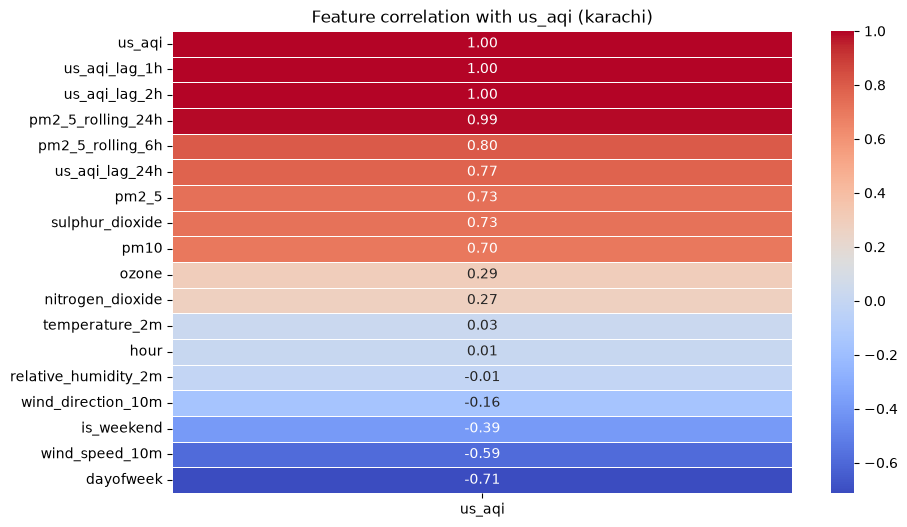

In [10]:
corr_matrix = df_karachi.corr()
#extract correlation values for target variable
aqi_correlations = corr_matrix['us_aqi'].sort_values(ascending=False) 

print("Feature Correaltion with us_aqi:")
print(aqi_correlations)

#plot correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix[['us_aqi']].sort_values(by='us_aqi',ascending=False),
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)
plt.title("Feature correlation with us_aqi (karachi)")
plt.show()


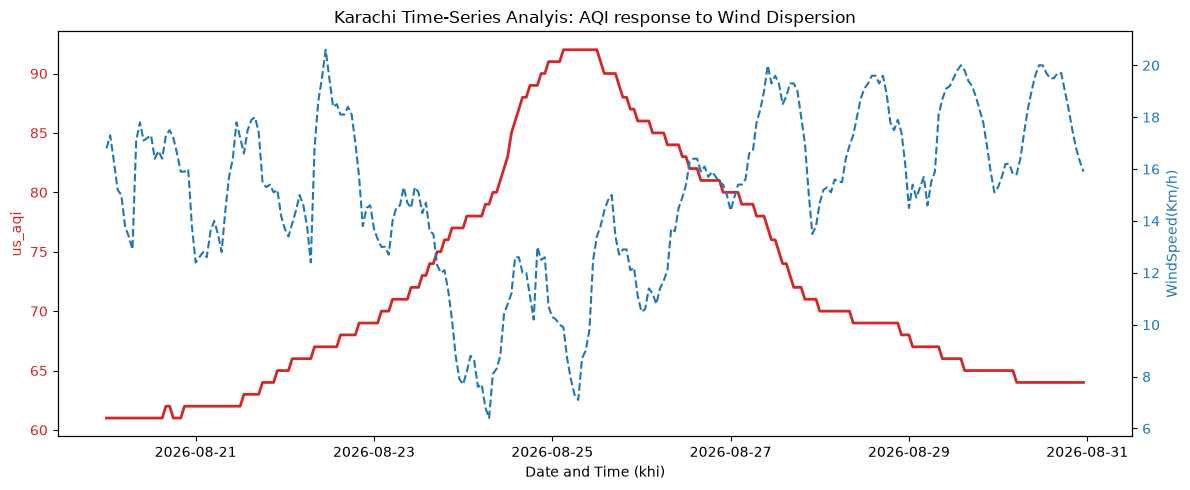

In [12]:
#dual axis plot for aqi vs windspeed ver time
fig,ax1 = plt.subplots(figsize=(12,5))

#primary y-axis: us_aqi
color="tab:red"
ax1.set_xlabel("Date and Time (khi)")
ax1.set_ylabel("us_aqi",color=color)
ax1.plot(df_karachi.index,df_karachi['us_aqi'],color=color, linewidth=2, label="AQI")
ax1.tick_params(axis='y',labelcolor=color)

#secondary y-axis:windspeed
ax2 = ax1.twinx()
color = "tab:blue"
ax2.set_ylabel("WindSpeed(Km/h)",color=color)
ax2.plot(df_karachi.index,df_karachi['wind_speed_10m'],color=color,linestyle='--',label="WindSpeed(10m)")
ax2.tick_params(axis='y',labelcolor=color)

plt.title("Karachi Time-Series Analyis: AQI response to Wind Dispersion")
fig.tight_layout()
plt.show()

